---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 11 – Detecção de Anomalias com Imagens

Neste notebook vamos aplicar técnicas de machine learning para identificar imagens anómalas — ou seja, imagens que se desviam do padrão esperado. Vamos explorar abordagens com autoencoders e embeddings para detetar desvios em conjuntos simples de imagens.
Um autoencoder aprende a representar dados comprimindo e reconstruindo a entrada.  
Se for treinado apenas com dados típicos de uma classe, ele **falhará** em reconstruir exemplos atípicos,  
pois nunca os viu durante o treino.  
A diferença entre a imagem original e a reconstruída — o *erro de reconstrução* — é o sinal de anomalia.

## 11.1. Setup

A célula importa as bibliotecas necessárias e prepara o ambiente PyTorch:
- **torch / torchvision** — frameworks principais para criação e treino de redes neurais;
- **matplotlib / numpy** — para visualização e manipulação de dados;
- **random** — para amostragem controlada;
- **device** — define se o treino ocorrerá em GPU (`cuda`) ou CPU.

O autoencoder será treinado sobre um subconjunto de dados “normais” (sem anomalias).  
Durante a inferência, exemplos “anómalos” produzirão **maior erro de reconstrução**,  
servindo como critério de deteção.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns
import pandas as pd
from torch.utils.data import ConcatDataset, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A utilizar: {device}")

A utilizar: cpu


## 11.2. Carregamento e preparação dos dados

Nesta célula, o conjunto **MNIST** é preparado para simular um problema de **deteção de anomalias**.  
A ideia é treinar o modelo apenas com exemplos de uma única classe (“normal”) e avaliar a sua capacidade  
de identificar imagens que não pertencem a essa classe (“anómalas”).

**Passos principais**

1. **Carregamento do dataset**
   - O MNIST é carregado com transformação simples para *tensor* (`ToTensor`),  
     resultando em imagens normalizadas no intervalo [0, 1].

2. **Separação por classes**
   - Escolhe-se a classe `1` como **classe normal**.
   - Todas as restantes (`0, 2, 3, …, 9`) são tratadas como **anomalias**.

3. **Criação dos subconjuntos**
   - `normal_subset`: 1000 imagens da classe normal para treino.
   - `anomalous_subset`: 100 imagens de outras classes, usadas apenas no teste.
   - `normal_test_subset`: 100 imagens adicionais da classe normal (diferentes do treino),  
     também para o conjunto de teste.

4. **Combinação dos conjuntos de teste**
   - O *ConcatDataset* junta `anomalous_subset` + `normal_test_subset`  
     para criar um *test_loader* misto com exemplos normais e anómalos.

**Objetivo**

Durante o treino, o modelo **só verá dígitos “1”**.  
Durante o teste, ele receberá tanto dígitos “1” (normais) como outros dígitos (anomalias).  
Ao comparar os **erros de reconstrução**, esperamos observar valores sistematicamente  
mais altos para as imagens anómalas.

Esta preparação é uma simulação clássica de *one-class learning* aplicada a imagens.

In [2]:
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

normal_class = 1
normal_data = [i for i, (img, label) in enumerate(mnist) if label == normal_class]
anomalous_data = [i for i, (img, label) in enumerate(mnist) if label != normal_class]

normal_subset = Subset(mnist, normal_data[:1000])
anomalous_subset = Subset(mnist, anomalous_data[:100])

train_loader = DataLoader(normal_subset, batch_size=32, shuffle=True)
# Extrair manualmente os índices da normal_subset
normal_indices = normal_data[100:200]
normal_test_subset = Subset(mnist, normal_indices)

# Combinar datasets manualmente com ConcatDataset
from torch.utils.data import ConcatDataset

test_dataset = ConcatDataset([anomalous_subset, normal_test_subset])
test_loader = DataLoader(test_dataset, batch_size=32)

## 11.3. Definição do Autoencoder

O modelo definido nesta célula é um **autoencoder totalmente conectado** (*fully connected autoencoder*),  
usado para aprender uma representação comprimida (latente) das imagens da classe normal.

**Estrutura**

- **Encoder (codificador)**
  - `Flatten()` — transforma a imagem 28×28 num vetor de 784 valores.
  - `Linear(784 → 256)` → `ReLU` → `Linear(256 → 64)` → `ReLU`  
    O modelo reduz progressivamente a dimensionalidade até um vetor de **64 neurónios**,  
    que funciona como a **representação latente** do padrão “normal”.

- **Decoder (descodificador)**
  - `Linear(64 → 256)` → `ReLU` → `Linear(256 → 784)` → `Sigmoid()`  
    Reconstrói a imagem original a partir da representação latente.  
    A ativação *Sigmoid* garante que os valores da saída permanecem no intervalo [0, 1].

**Interpretação**

Durante o treino, o autoencoder aprende a **reproduzir imagens “normais”** com erro mínimo.  
Como nunca vê exemplos anómalos, ele **falhará** em reconstruí-los corretamente,  
produzindo **maior erro de reconstrução** — o principal indicador de anomalia.

> Este modelo é deliberadamente simples e rápido de treinar.  
> Em aplicações reais, pode-se substituir o encoder/decoder por camadas convolucionais  
> (CNN Autoencoder) como no notebook 8 para capturar estruturas espaciais mais complexas.

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
    (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)


## 11.4. Treino do modelo

Treinamos o autoencoder apenas com imagens **normais**.

Esta célula treina o autoencoder para **reconstruir apenas imagens da classe normal** (neste caso, o dígito `1`).  
O modelo aprende a comprimir e reconstruir essas imagens de forma eficiente, minimizando o erro médio quadrático (MSE).

**Estrutura do treino**

- **Função de perda**  
  `MSELoss()` — mede o erro de reconstrução entre a imagem de entrada e a saída reconstruída.  
  Quanto menor o valor, melhor o modelo consegue reproduzir os padrões “normais”.

- **Otimizador**  
  `Adam` com `lr=0.001` — oferece convergência rápida e estável.

- **Treino**  
  Cada época percorre todo o *loader* de treino (`train_loader`),  
  calculando gradientes e atualizando os pesos da rede.

- **Barra de progresso (`tqdm`)**  
  Mostra em tempo real o valor da perda de cada batch e o *Loss médio* por época,  
  permitindo monitorizar a estabilidade e convergência do modelo.

**Nota pedagógica**

Durante o treino:
- As perdas tendem a diminuir de forma suave e estável.
- Se o *Loss* se estabilizar demasiado cedo, pode-se aumentar o número de épocas.  
- Se oscilar fortemente, pode-se reduzir a *learning rate*.

Após o treino, o modelo deve conseguir reconstruir imagens “1” com baixo erro —  
mas apresentará erros significativamente mais altos quando tentar reconstruir outros dígitos,  
o que será explorado na próxima etapa (deteção de anomalias).

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Época {epoch+1}', leave=False)
    for images, _ in pbar:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    print(f"Época {epoch+1}, Loss médio: {running_loss / len(train_loader):.4f}")

Época 1, Loss médio: 0.0997


Época 2, Loss médio: 0.0293


Época 3, Loss médio: 0.0213


Época 4, Loss médio: 0.0193


Época 5, Loss médio: 0.0168


...

Época 46, Loss médio: 0.0029


Época 47, Loss médio: 0.0028


Época 48, Loss médio: 0.0028


Época 49, Loss médio: 0.0028


Época 50, Loss médio: 0.0027


## 11.5. Detecção de anomalias via reconstrução

Calculamos o erro de reconstrução para imagens de teste. As que têm erro alto são consideradas anómalas.

Depois do treino, o autoencoder é usado para reconstruir imagens **normais e anómalas**.  
A comparação entre a imagem original e a reconstruída permite calcular um **erro de reconstrução**  
para cada amostra — este erro é a métrica central para a deteção de anomalias.

**Passos da célula**

1. **Cálculo do erro**
   - Para cada imagem de teste, calcula-se o erro médio quadrático (MSE) entre a imagem original e a reconstruída:
     \[
     \text{erro} = \frac{1}{N}\sum (x - \hat{x})^2
     \]
   - Este valor é guardado como *anomaly score*.

2. **Seleção de amostras mais anómalas**
   - Ordenam-se as imagens segundo o erro.
   - As 10 com maior erro são selecionadas para visualização.

3. **Visualização**
   - Cada linha mostra:
     - **Original:** imagem de entrada.
     - **Reconstruída:** saída do autoencoder.
     - **Mapa de erro:** diferença absoluta pixel a pixel (realçada em tons quentes).
   - O título de cada mapa indica o valor do erro médio de reconstrução.

**Interpretação dos resultados**

- As imagens **normais** (dígito “1”) são reconstruídas com alta fidelidade → erro baixo.  
- As imagens **anómalas** (outros dígitos) são mal reconstruídas → erro alto e difuso.  
  Isto acontece porque o modelo nunca aprendeu os seus padrões durante o treino.

O **mapa de erro** serve assim como uma forma visual de *heatmap de anomalia*:
- zonas vermelhas → partes inesperadas para o modelo, onde falhou a reconstrução;
- zonas escuras → regiões bem representadas.

**Possíveis extensões**

- **Curva ROC / AUC:** comparar distribuição dos erros normais vs. anómalos.
- **Threshold adaptativo:** calcular o limiar ótimo automaticamente (ex: média + 3×desvio padrão).
- **Aplicação real:** imagens médicas, inspeção industrial, deteção de falhas em vídeo, etc.


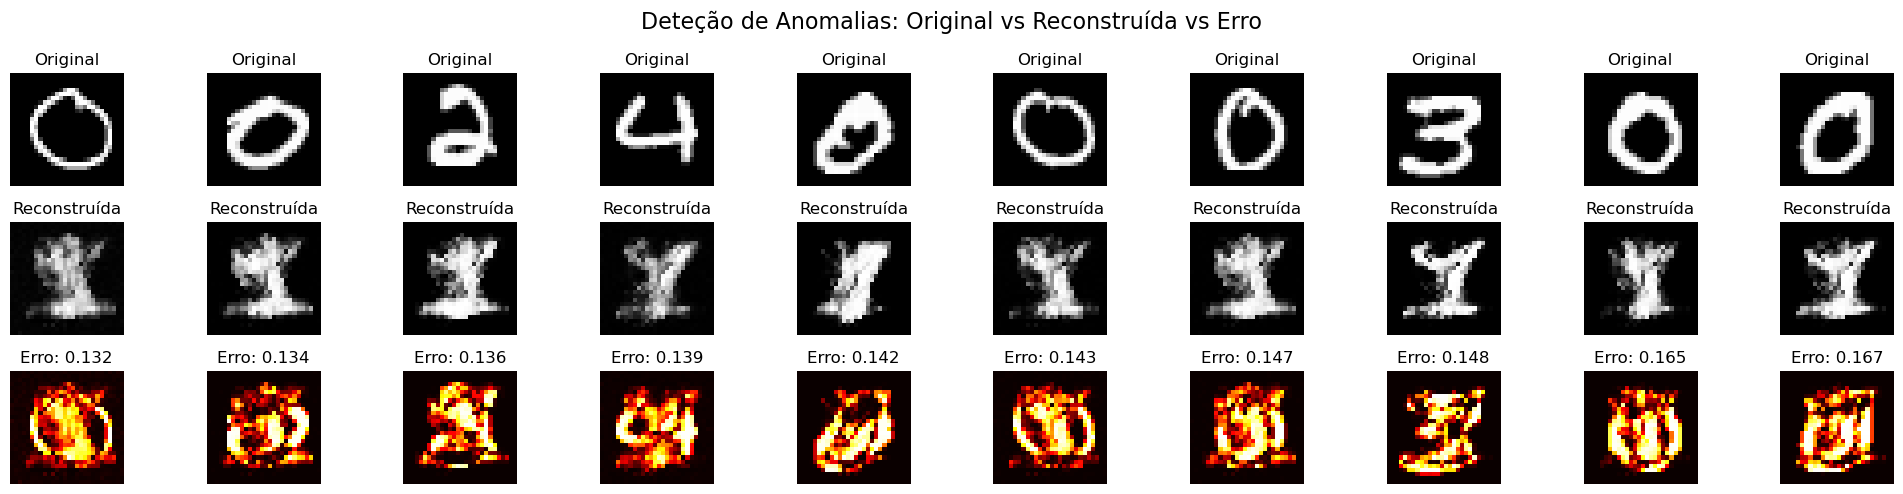

In [5]:
model.eval()
threshold = 0.02
original_images = []
reconstructed_images = []
anomaly_scores = []
labels = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        loss = ((images - outputs) ** 2).view(images.size(0), -1).mean(dim=1)

        anomaly_scores.extend(loss.cpu().numpy())
        labels.extend(targets.numpy())
        original_images.extend(images.cpu())
        reconstructed_images.extend(outputs.cpu())

# --- Combinar subconjuntos para visualização ---
extra_normals = Subset(mnist, normal_data[100:200])
all_test = ConcatDataset([anomalous_subset, extra_normals])

# --- Obter todas as imagens ---
all_images, _ = next(iter(DataLoader(all_test, batch_size=len(all_test))))

# --- Selecionar 10 imagens com maior erro ---
top_anomalies = np.argsort(anomaly_scores)[-10:]

# Mostrar reconstrução vs original vs mapa de erro
n = 5  # Quantas imagens mostrar
top_idxs = np.argsort(anomaly_scores)[-n:]

model.eval()
all_images, _ = next(iter(DataLoader(all_test, batch_size=len(all_test))))
images_to_show = all_images[top_idxs].to(device)

with torch.no_grad():
    reconstructions = model(images_to_show)

# Mostrar 10 imagens com maior erro
top_anomalies = np.argsort(anomaly_scores)[-10:]

plt.figure(figsize=(20, 5))
for i, idx in enumerate(top_anomalies):
    orig = original_images[idx]
    recon = reconstructed_images[idx]
    diff = torch.abs(orig - recon)

    plt.subplot(3, 10, i+1)
    plt.imshow(orig.squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 10, 10+i+1)
    plt.imshow(recon.squeeze(), cmap='gray')
    plt.title("Reconstruída")
    plt.axis('off')

    plt.subplot(3, 10, 20+i+1)
    plt.imshow(diff.squeeze(), cmap='hot')
    plt.title(f"Erro: {anomaly_scores[idx]:.3f}")
    plt.axis('off')

plt.suptitle("Deteção de Anomalias: Original vs Reconstruída vs Erro", fontsize=16)
plt.tight_layout()
plt.show()

## 11.6. Distribuição dos Erros de Reconstrução

Esta célula mostra a **distribuição dos erros de reconstrução** de todas as imagens de teste.  
Cada valor no eixo X representa o erro médio de uma imagem (a diferença entre a imagem original e a reconstruída),  
enquanto o eixo Y indica quantas imagens apresentaram aquele nível de erro.

**Interpretação**

- A maioria das imagens apresenta **erros baixos**, concentrando-se à esquerda do histograma —  
  estas correspondem à **classe normal** (dígitos “1”), que o autoencoder aprendeu a reconstruir bem.  
- As imagens com **erros altos**, mais à direita, são as **anomalias** (outros dígitos),  
  que o modelo não consegue reconstruir corretamente.

A **linha vermelha tracejada** representa o **limiar de decisão (`threshold`)** usado para classificar:
- abaixo do limiar → *normal*  
- acima do limiar → *anómalo*

**Nota pedagógica**

O limiar pode ser ajustado empiricamente ou determinado com métodos automáticos:
- percentil de erro (ex: 95.º percentil),
- média + 3×desvio padrão,
- otimização com métricas como *precision-recall*.

Com este histograma, os estudantes podem visualizar de forma imediata a separação entre padrões normais e anómalos,  
e compreender como o **erro de reconstrução** atua como métrica de deteção.

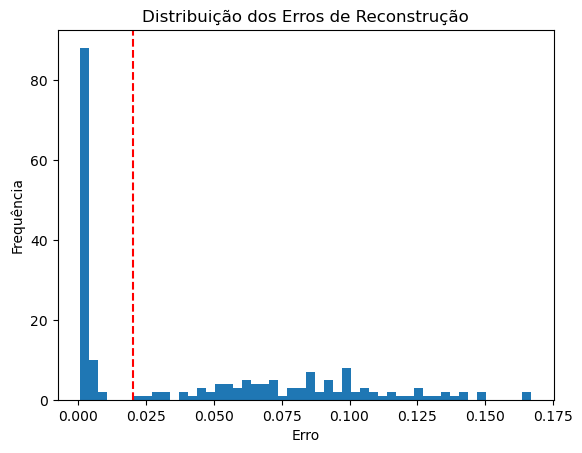

In [6]:
plt.hist(anomaly_scores, bins=50)
plt.axvline(x=threshold, color='r', linestyle='--')
plt.title("Distribuição dos Erros de Reconstrução")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

## 11.7. Análise de Erro por Classe

Este gráfico de caixa (*boxplot*) mostra a **distribuição dos erros de reconstrução por classe** do dataset.  
Cada caixa representa os valores de erro de reconstrução (MSE) para uma classe específica do MNIST.

**Interpretação**

- A classe **1** (a classe normal usada no treino) apresenta uma **distribuição estreita e erros baixos**,  
  indicando que o autoencoder consegue reconstruir bem esses exemplos.
- As **outras classes** exibem **erros médios e dispersões maiores**,  
  o que revela falhas de reconstrução e, portanto, **anomalias**.

Isto ilustra de forma clara o princípio central da deteção de anomalias com autoencoders:
> “O modelo reconstrói bem apenas o que aprendeu — o resto é anómalo.”

**Reflexão**

Esta visualização permite:
- comparar visualmente a separação entre classes normais e anómalas;
- verificar a robustez do limiar definido no histograma anterior;
- explorar cenários onde há *overlap* de erros — casos ambíguos que podem motivar refinamento do modelo  
  (ex: introduzir regularização, aumentar o treino ou usar um autoencoder convolucional).


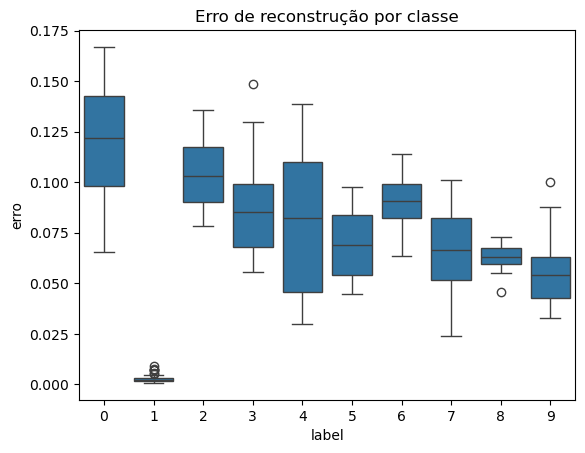

In [7]:
df = pd.DataFrame({'label': labels, 'erro': anomaly_scores})
sns.boxplot(x='label', y='erro', data=df)
plt.title("Erro de reconstrução por classe")
plt.show()

## 11.8. [Future Work]: Estética da Normalidade — Anomalias como Violações de Estilo
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Reformular a deteção de anomalias como um problema estético: o que significa uma imagem ser “normal”?
Explorar a ideia de que uma anomalia visual pode corresponder a uma violação estética — de composição, iluminação ou harmonia formal.

Pipeline sugerido:

	•	Construir um dataset com imagens “esteticamente normais” (ex: fotografias bem compostas, obras clássicas).
	•	Gerar variações que perturbem essa normalidade (cortes, distorções, desequilíbrios).
	•	Treinar autoencoders ou modelos contrastivos para aprender a “norma estética”.
	•	Analisar os casos de erro como indicadores de anomalia perceptiva.
	•	Discutir implicações filosóficas: até que ponto a IA aprende o gosto humano?

Potencial: aproximação entre computational aesthetics e unsupervised learning, abrindo espaço a investigação estética e cultural em IA.

## 11.9. [Future Work]: Autoencoders como Guias para Geração Anómala em Modelos de Difusão
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Usar autoencoders treinados em conjuntos “normais” para guiar modelos de difusão na geração de imagens fora da distribuição.
O objetivo é produzir imagens plausíveis mas estruturalmente “estranhas”, úteis para robustez, adversarial training ou arte generativa.

Pipeline sugerido:

	•	Treinar um autoencoder simples em imagens de referência (ex: CIFAR‑10 ou ImageNet subset).
	•	Integrar o erro de reconstrução como sinal externo durante a geração com Stable Diffusion.
	•	Maximizar esse erro para promover a geração de imagens anómalas.
	•	Analisar os padrões de anomalia: forma, textura, semântica?
	•	Avaliar se estas imagens desafiam classificadores ou modelos perceptivos humanos.

Potencial: convergência entre anomaly detection e generative modeling, com aplicações em robustez e criatividade computacional.

## 11.10. [Future Work]: Explicações Simbólicas para Anomalias Visuais
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Ir além dos mapas de ativação (Grad‑CAM, LIME) e gerar descrições simbólicas ou linguísticas sobre o que torna uma imagem anómala.
Investigar como os erros de reconstrução podem ser traduzidos em linguagem natural, explicando o tipo e a localização da anomalia.

Pipeline sugerido:

	•	Treinar um autoencoder em imagens normais e recolher erros de reconstrução.
	•	Usar um modelo multimodal (ex: CLIP, BLIP‑2, ou GPT‑4V) para gerar descrições textuais das zonas de erro.
	•	Classificar os tipos de anomalia: “ruído estrutural”, “forma inesperada”, “ausência de detalhe”.
	•	Mapear as explicações para clusters semânticos de anomalias.
	•	Discutir como esta abordagem contribui para transparência e interpretabilidade em visão artificial.

Potencial: combinação de explainable AI com vision‑language modeling, ainda pouco explorada para anomalias visuais não supervisionadas.

## 11.11. [Future Work]: Anomalias Temporais em Vídeo — Quebras de Continuidade e Estranheza Visual
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Aplicar técnicas de deteção de anomalias a vídeo, com o objetivo de identificar momentos de colapso perceptivo — quebras de continuidade, frames incoerentes ou falhas de consistência geradas por IA.
|
Pipeline sugerido:

	•	Gerar vídeos com modelos de difusão (ex: Runway, Pika, Sora, etc.).
	•	Extrair frames e medir coerência temporal com métricas como LPIPS, CLIP similarity e optical flow.
	•	Detetar frames “fora da sequência” ou com anomalias perceptuais marcadas.
	•	Visualizar as falhas com heatmaps ou diferenças de embedding.
	•	Analisar se estas falhas coincidem com momentos de uncanny valley ou estranheza narrativa.

Potencial: contribuição inédita para avaliação da qualidade e coerência temporal em geração de vídeo com IA.

## 11.12. Discussão e Considerações

Esta abordagem é simples, mas ilustra como reconstrução pode ser usada para detectar outliers. Em aplicações reais, é necessário considerar:

- Escolha adequada do threshold
- Métricas robustas (ex: AUC-ROC)
- Datasets balanceados e com contexto do domínio